# Projet : Algorithme de Dijkstra

## 1.Objectif du Projet

L'objectif de ce projet est d'explorer et de comparer les performances de deux implémentations de l'**algorithme de Dijkstra** : 
1. Une **version naïve**.
2. Une **version optimisée** à l'aide d'une structure de tas.

Ces implémentations permettront de résoudre le problème du **plus court chemin** dans des **graphes pondérés**. En utilisant une classe `Graph`, le projet vise à **générer des graphes aléatoires** de différentes tailles et densités (graphes complets et épars). L'objectif final est **d'analyser les temps d'exécution** des deux versions.


## 2.Plan du Projet

1. **Objectif du Projet**
2. **Plan du Projet**
3. **Introduction**
4. **Structure du Code Python**
5. **Implementation des deux versions de l'algorithme de dikshtra**
6. **Analyse Théorique**
7. **Analyse empirique: Études de Cas**
   - Cas 1 : Graphe avec multi-arêtes
   - Cas 2 : Petit graphe
   - Cas 3 : Grand graphe
8. **Comparaison des performances des deux versions**
9. **Conclusion**

## 3.Introduction

L'algorithme de **Dijkstra** est une méthode célèbre et fondamentale utilisée pour résoudre le problème du **plus court chemin** dans un **graphe pondéré**. Il a été conçu par **Edsger Dijkstra** en **1956** et reste l'une des bases de l'algorithmique en théorie des graphes.

L'objectif principal de l'algorithme est de **trouver la distance minimale** entre un sommet source donné et **tous les autres sommets** du graphe. Cela revient à **déterminer les chemins les plus courts**, c'est-à-dire ceux avec le **poids total le plus faible**.

### Fonctionnement général

#### 1. Initialisation :
   - Une structure `distances` est initialisée avec une valeur **infinie (+∞)** pour tous les sommets, sauf le **sommet source** (initialisé à **0**).
   - Une structure `visited` suit les sommets **déjà traités**.

#### 2. Principe de relaxation :
   - Lorsqu'un sommet est sélectionné, **tous ses voisins** sont analysés.
   - Si un chemin **plus court** est trouvé via ce sommet, la distance est **mise à jour**.

#### 3. Sélection du sommet suivant :
   - Le **sommet non visité** ayant la plus petite distance est sélectionné.

#### 4. Répétition :
   - Ces étapes sont répétées **jusqu'à ce que tous les sommets soient traités**.



### Points Essentiels de Dijkstra

1. **Nature du Graphe :**  
   - Fonctionne **uniquement** sur des **graphes pondérés** avec **poids positifs**.  
   - Il **ne fonctionne pas** correctement avec **des poids négatifs**.

2. **Structure Interne :**  
   - Maintient une distinction entre **sommets visités** et **non visités**.

3. **Reconstruction du Chemin :**  
   - Il est possible de **retracer** les **chemins les plus courts** en conservant les arêtes utilisées.




## 4.Structure de code et test unitaire

### La classe Graph

La classe `Graph` implémente une structure de graphe utilisant une **matrice d'adjacence** et une **liste d'adjacence**.  
Elle propose plusieurs méthodes permettant **d'ajouter et de supprimer** des **sommets** et des **arêtes**, ainsi que **d'afficher** la représentation interne du graphe.  
Les **tests unitaires** permettent de **valider le bon fonctionnement** de ces méthodes.

### 1. Méthodes du Graph

- `__init__(num_vertices)` :  
  Initialise un graphe avec `num_vertices` sommets en créant **une matrice d'adjacence remplie de zéros** et une **liste d'adjacence vide**.

- `add_edge(u, v, weight)` :  
  Ajoute **une arête pondérée** entre les sommets `u` et `v`. La matrice et la liste d'adjacence sont mises à jour pour stocker cette arête.

- `remove_edge(u, v)` :  
  Supprime **l’arête entre `u` et `v`** en mettant la valeur à `0` dans la matrice et en supprimant l’entrée correspondante dans la liste d'adjacence.

- `add_vertex()` :  
  Ajoute un **nouveau sommet** en agrandissant **la matrice** et en initialisant **une nouvelle entrée** dans la liste d'adjacence.

- `remove_vertex(v)` :  
  Supprime un **sommet** et met à jour **la matrice** ainsi que **la liste d’adjacence**.  
  Tous les **sommets de plus grand index** sont **réindexés** pour assurer la cohérence du graphe.

- `display_internal_representation()` :  
  Affiche **la matrice et la liste d'adjacence** dans un format lisible.

- `display_A_S_lists()` :  
  Génère et affiche **la liste des arêtes (`A`)** et **des sommets (`S`)** du graphe.

- `display_degrees()` :  
  Calcule et affiche **le degré de chaque sommet**.

- `draw()` :  
  Génère **une représentation graphique du graphe** en utilisant **NetworkX** et **Matplotlib**.


In [10]:
from dijkstra_shortest_path import *

In [11]:
%matplotlib inline

### 2. Tests Unitaires
Pour garantir le **bon fonctionnement** de chaque méthode, nous avons implémenté plusieurs **tests unitaires** :

#### **Tests pour `add_vertex`** :
- Vérification de **l’ajout d’un sommet** et de **l’expansion correcte** de la **matrice** et de la **liste d'adjacence**.

In [12]:
g = Graph(3)
g.add_vertex()
assert g.num_vertices == 4
assert len(g.adj_matrix) == 4
assert len(g.adj_matrix[0]) == 4
assert 3 in g.adj_list
print("✅ add_vertex fonctionne correctement.")

✅ add_vertex fonctionne correctement.


#### **Tests pour `add_edge`** :
- Vérification de **l’ajout correct d’une arête** dans la **matrice** et **la liste d’adjacence**.
- Gestion des **cas invalides** (sommets hors limites, **boucles interdites**).

In [13]:
g = Graph(5)
g.add_edge(0, 1, 10)
assert g.adj_matrix[0][1] == 10
assert g.adj_matrix[1][0] == 10
assert (1, 10) in g.adj_list[0]
assert (0, 10) in g.adj_list[1]
print("✅ add_edge fonctionne correctement pour un cas valide.")

✅ add_edge fonctionne correctement pour un cas valide.


#### **Tests pour `remove_vertex`** :
- Vérification de la **suppression correcte d’une arête**.
- Test d’un appel sur **une arête inexistante** (ne doit **pas provoquer d’erreur**).


In [14]:
g = Graph(4)
g.add_edge(0, 1, 5)
g.add_edge(1, 2, 7)
g.add_edge(2, 3, 4)
g.remove_vertex(1)
assert g.num_vertices == 3
assert len(g.adj_matrix) == 3
assert len(g.adj_matrix[0]) == 3
print("✅ remove_vertex fonctionne correctement.")


✅ remove_vertex fonctionne correctement.


#### **Tests pour `remove_edge`** :
- Vérification de la **suppression correcte d’une arête**.
- Test d’un appel sur **une arête inexistante** (ne doit **pas provoquer d’erreur**).


In [15]:
g = Graph(5)
g.add_edge(0, 1, 10)
g.remove_edge(0, 1)
assert g.adj_matrix[0][1] == 0
assert g.adj_matrix[1][0] == 0
assert (1, 10) not in g.adj_list[0]
assert (0, 10) not in g.adj_list[1]
print("✅ remove_edge fonctionne correctement.")

✅ remove_edge fonctionne correctement.


#### **Tests pour `display_internal_representation()`** :
-  Vérifier que la matrice et la liste d’adjacence s’affichent sans erreur.




In [16]:
g = Graph(3)
g.add_edge(0, 1, 5)
g.add_edge(1, 2, 7)
g.display_internal_representation()  # Vérification visuelle
print("✅ display_internal_representation fonctionne correctement.")



Matrice d'adjacence:
╒════╤══════╤══════╤══════╕
│    │   S0 │   S1 │   S2 │
╞════╪══════╪══════╪══════╡
│  0 │    0 │    5 │    0 │
├────┼──────┼──────┼──────┤
│  1 │    5 │    0 │    7 │
├────┼──────┼──────┼──────┤
│  2 │    0 │    7 │    0 │
╘════╧══════╧══════╧══════╛

Liste d'adjacence:
╒═════════════════════════╕
│ Adjacency List          │
╞═════════════════════════╡
│ Γ(0) = [(1, 5)]         │
├─────────────────────────┤
│ Γ(1) = [(0, 5), (2, 7)] │
├─────────────────────────┤
│ Γ(2) = [(1, 7)]         │
╘═════════════════════════╛
✅ display_internal_representation fonctionne correctement.


#### **Tests pour `display_A_S_lists()`** :
- Vérifier que les listes des arêtes A et des sommets S sont correctement générées et affichées.



In [17]:
g = Graph(3)
g.add_edge(0, 1, 5)
g.add_edge(1, 2, 7)
g.display_A_S_lists()  # Vérification visuelle
print("✅ display_A_S_lists fonctionne correctement.")



A = { (0, 1, 5), (1, 2, 7) }
S = { 0, 1, 2 }
✅ display_A_S_lists fonctionne correctement.


#### **Tests pour `display_degrees()`** :
-  Vérifier que la méthode affiche correctement le degré de chaque sommet.




In [18]:
g = Graph(4)
g.add_edge(0, 1, 5)
g.add_edge(1, 2, 7)
g.add_edge(1, 3, 4)
g.display_degrees()  # Vérification visuelle
print("✅ display_degrees fonctionne correctement.")



Tableau des degrés :
╒══════════╤═════════╕
│ Sommet   │   Degré │
╞══════════╪═════════╡
│ Sommet 0 │       1 │
├──────────┼─────────┤
│ Sommet 1 │       3 │
├──────────┼─────────┤
│ Sommet 2 │       1 │
├──────────┼─────────┤
│ Sommet 3 │       1 │
╘══════════╧═════════╛
✅ display_degrees fonctionne correctement.


## **5.Implementation des deux versions de l'algorithme de dikshtra** 

### Version Naïve de l'Algorithme de Dijkstra

La **version naïve** de l'algorithme de **Dijkstra** repose sur une approche **itérative** pour **trouver le chemin le plus court** dans un **graphe pondéré**.  
Elle utilise une **simple liste** pour **stocker les sommets non visités** et choisit à chaque étape **le sommet ayant la plus petite distance actuelle**, en parcourant **l'ensemble des sommets non visités** à chaque itération.  

In [19]:
def dijkstra_naive(graph, start):
    # Vérifiez si le graphe est valide
    if not isinstance(graph, Graph):
        print("L'objet fourni n'est pas un graphe valide.")
        return None
    if graph is None:
        print("Le graphe est invalide. Impossible d'exécuter l'algorithme.")
        return None

    # Initialisation des distances
    distances = {vertex: float('inf') for vertex in graph.adj_list}
    distances[start] = 0
    visited = set()

    while len(visited) < len(graph.adj_list):
        min_vertex = None
        min_distance = float('inf')

        for vertex in graph.adj_list:
            if vertex not in visited and distances[vertex] < min_distance:
                min_vertex = vertex
                min_distance = distances[vertex]

        if min_vertex is None:
            break

        visited.add(min_vertex)

        for neighbor, weight in graph.adj_list[min_vertex]:
            if neighbor not in visited:
                new_distance = distances[min_vertex] + weight
                if new_distance < distances[neighbor]:
                    distances[neighbor] = new_distance

    return distances

### Version Optimisée de l'Algorithme de Dijkstra

La **version optimisée** de l'algorithme de **Dijkstra** améliore considérablement **les performances** en utilisant une **structure de données appelée tas binaire (min-heap)**.  
Le **tas** permet de sélectionner rapidement le sommet avec **la plus petite distance** en **O(log V)**, au lieu de **O(V)** dans la version naïve.  

In [20]:
def dijkstra_optimized(graph, start):
    # Vérifiez si le graphe est valide
    if not isinstance(graph, Graph):
        print("L'objet fourni n'est pas un graphe valide.")
        return None
    if graph is None:
        print("Le graphe est invalide. Impossible d'exécuter l'algorithme.")
        return None

    import heapq  # Import nécessaire pour la version optimisée
    distances = {vertex: float('inf') for vertex in graph.adj_list}
    distances[start] = 0
    priority_queue = [(0, start)]  # Min-heap to store (distance, vertex)

    while priority_queue:
        current_distance, current_vertex = heapq.heappop(priority_queue)

        # Ignore les distances obsolètes
        if current_distance > distances[current_vertex]:
            continue

        for neighbor, weight in graph.adj_list[current_vertex]:
            new_distance = distances[current_vertex] + weight

            if new_distance < distances[neighbor]:
                distances[neighbor] = new_distance
                heapq.heappush(priority_queue, (new_distance, neighbor))

    return distances

## 6.Analyse Théorique

### Version Naïve de Dijkstra

1. **Description :**
   - On commence avec un **ensemble des sommets non visités**.
   - À chaque itération, on **cherche manuellement** le **sommet avec la plus petite distance**.
   - Ensuite, on met à jour **les distances des voisins**.

2. **Complexité :**
   - **O(V² + E)** ou approximativement **O(V²)** (si **E** est petit par rapport à **V²**).


### Version Optimisée de Dijkstra (avec un tas min)

1. **Description :**
   - Utilise une **structure de données prioritaire** (`tas min`).
   - Gestion efficace du **sommet minimal**.

2. **Complexité :**
   - **O((V + E) log V)**


### Comparaison Théorique des Deux Versions

| Critère               | Version Naïve  | Version Optimisée |
|-----------------------|---------------|-------------------|
| **Complexité**       | O(V²)         | O((V + E) log V) |
| **Structure**        | Tableaux      | Tas min          |
| **Efficacité (dense)** | O(V²)        | O(V² log V)      |
| **Efficacité (épars)** | Lent         | Rapide           |


### Conclusion Théorique

- **Version naïve :**  
   **Simple** à implémenter  
   **Lente** pour les grands graphes  

- **Version optimisée :**  
   **Performante** pour les **grands graphes**  
   **Structure plus complexe** (tas min)  


## 7.Analyse Empirique

Dans cette partie, on va tester les deux algorithmes sur différent graphe suivant chaque cas pour enfin les comparer.

### Études de Cas

#### Cas 1 : Génération d’un Graphe Connexe et Contraintes Mathématiques


Lors de la génération d’un **graphe connexe** avec un nombre spécifique de **sommets** et **d’arêtes**, il est essentiel de respecter certaines **propriétés mathématiques fondamentales** des graphes.

#### Nombre maximal d’arêtes dans un graphe simple

Pour un **graphe simple** (sans arêtes multiples entre les mêmes sommets) avec **N sommets**, le **nombre maximal d’arêtes possibles** est donné par la formule suivante :

Nombre maximal d’arêtes = N \(N + 1)/2

#### Détection des limites dans le programme

Ce cas met en évidence **une situation où le nombre d’arêtes demandé dépasse cette limite théorique**.  
Par exemple, **une demande de 22 arêtes** pour **6 sommets** **dépasse cette limite** et est détectée par le programme.

#### Gestion de cette contrainte

- Le **programme vérifie en amont** si le nombre d’arêtes demandé est **compatible** avec les propriétés du graphe.
- Si la **limite est dépassée**, un **message clair est affiché** pour informer l’utilisateur.
- Cette gestion garantit que **seuls des graphes valides** sont **générés et analysés** dans l’expérimentation.


In [21]:
graph1 = generate_and_display_graph(6, 22, (1, 10), is_connected=False)

❌ Erreur : Le nombre d'arêtes demandé (22) dépasse la limite maximale (21) pour 6 sommets.


In [22]:
dijkstra_optimized(graph1, 4)

L'objet fourni n'est pas un graphe valide.


In [23]:
dijkstra_naive(graph1, 4)

L'objet fourni n'est pas un graphe valide.


In [24]:
compare_algorithms(graph1, 4,dijkstra_naive, dijkstra_optimized)

❌ Erreur : Le graphe fourni n'est pas valide. Impossible de comparer les algorithmes.


(None, None)

#### Gestion des Poids Négatifs dans la Génération du Graphe
L'algorithme de Dijkstra ne fonctionne pas correctement avec des poids négatifs car il repose sur le principe que la plus courte distance trouvée pour un sommet est définitive une fois calculée. Lorsqu’un graphe contient des arêtes de poids négatif, il devient possible qu’une autre route, découverte plus tard, réduise encore plus la distance minimale, ce que Dijkstra ne peut pas gérer efficacement. Pour éviter cette incohérence, une vérification stricte des poids est intégrée dès la génération du graphe.

Dans notre gestion, avant même de créer un graphe, nous vérifions si l’intervalle des poids contient des valeurs négatives. Si c’est le cas, la génération est immédiatement stoppée, et un message d’erreur explicite est affiché pour informer l’utilisateur que les poids négatifs sont incompatibles avec l’algorithme utilisé. Cette vérification empêche ainsi toute exécution incorrecte et garantit que le graphe généré pourra être traité efficacement par Dijkstra.

Grâce à cette approche, nous évitons tout comportement inattendu et nous assurons que seuls des poids positifs ou nuls sont utilisés dans les calculs, garantissant ainsi la robustesse et la fiabilité des résultats. 

In [25]:
graph2 = generate_and_display_graph(10, 55, (-10, 10), is_connected=True)

❌ Erreur : Les poids négatifs ne sont pas compatibles avec l'algorithme de Dijkstra.
🔹 Veuillez choisir un intervalle de poids positif.


In [26]:
dijkstra_optimized(graph2, 4)

L'objet fourni n'est pas un graphe valide.


In [27]:
dijkstra_naive(graph2, 4)

L'objet fourni n'est pas un graphe valide.


In [28]:
compare_algorithms(graph2, 4,dijkstra_naive, dijkstra_optimized)

❌ Erreur : Le graphe fourni n'est pas valide. Impossible de comparer les algorithmes.


(None, None)

####  Cas 2 : **Petit Graphe**

Dans ce cas, nous analysons les performances des **versions naïve et optimisée** de l’**algorithme de Dijkstra** sur des **graphes de petite taille**.  
Un **petit graphe** se caractérise par un **nombre limité de sommets et d’arêtes**, ce qui **réduit considérablement la charge de calcul** pour les deux versions.


##### Etape 1: Géneration de graph aléatoire


Matrice d'adjacence:
╒════╤══════╤══════╤══════╤══════╤══════╕
│    │   S0 │   S1 │   S2 │   S3 │   S4 │
╞════╪══════╪══════╪══════╪══════╪══════╡
│  0 │    0 │    9 │    0 │    0 │    0 │
├────┼──────┼──────┼──────┼──────┼──────┤
│  1 │    9 │    0 │    3 │    0 │    0 │
├────┼──────┼──────┼──────┼──────┼──────┤
│  2 │    0 │    3 │    0 │    3 │    0 │
├────┼──────┼──────┼──────┼──────┼──────┤
│  3 │    0 │    0 │    3 │    0 │   10 │
├────┼──────┼──────┼──────┼──────┼──────┤
│  4 │    0 │    0 │    0 │   10 │    0 │
╘════╧══════╧══════╧══════╧══════╧══════╛

Liste d'adjacence:
╒══════════════════════════╕
│ Adjacency List           │
╞══════════════════════════╡
│ Γ(0) = [(1, 9)]          │
├──────────────────────────┤
│ Γ(1) = [(0, 9), (2, 3)]  │
├──────────────────────────┤
│ Γ(2) = [(1, 3), (3, 3)]  │
├──────────────────────────┤
│ Γ(3) = [(2, 3), (4, 10)] │
├──────────────────────────┤
│ Γ(4) = [(3, 10)]         │
╘══════════════════════════╛

A = { (0, 1, 9), (1, 2, 3), (2, 3,

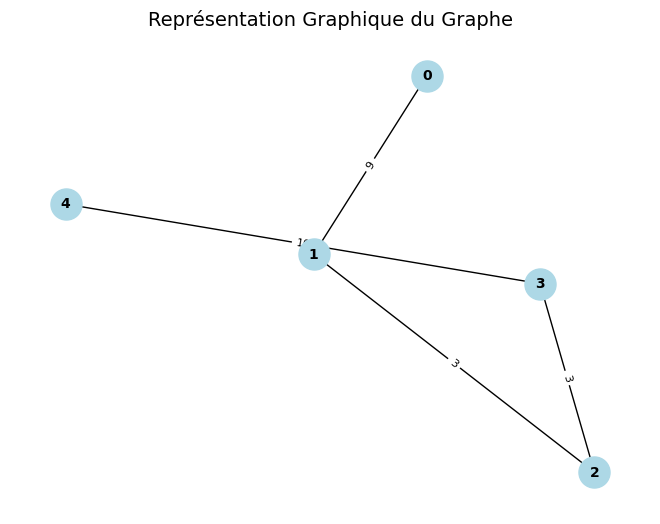

In [29]:
graph3 = generate_and_display_graph(5, 5, (1, 10), is_connected=True)

#### Etape 2: Calcule de distance à l'aide des deux version de l'algorithme

In [30]:
dijkstra_optimized(graph3, 4)

{0: 25, 1: 16, 2: 13, 3: 10, 4: 0}

In [31]:
dijkstra_naive(graph3, 4)

{0: 25, 1: 16, 2: 13, 3: 10, 4: 0}

#### Etape3: Comparaison entre les Deux Versions

In [32]:
compare_algorithms(graph3, 4,dijkstra_naive, dijkstra_optimized)


🔹 **Comparaison des Algorithmes de Dijkstra**
🔵 Dijkstra Naïf : 0.000033 secondes
🟢 Dijkstra Optimisé (Tas) : 0.000015 secondes
✅ L'algorithme optimisé est plus rapide.


(3.260001540184021e-05, 1.479999627918005e-05)

#### **Version naïve** :
- Fonctionne directement en **parcourant tous les sommets** pour chaque étape, sans structure optimisée.
- Le **temps d’exécution** est limité par **V** et **E**, mais cela reste **négligeable** sur un **graphe de petite taille**.

#### **Version optimisée** :
- Utilise un **tas min** pour gérer les priorités, mais le temps passé à **initialiser et gérer cette structure** est similaire à celui des opérations dans la version **naïve** pour un **petit graphe**.

---

#### Pourquoi le Temps d’Exécution est Similaire ?

Pour les **petits graphes**, le **nombre d'opérations** nécessaires à chaque étape de l'algorithme (**recherche du sommet minimum, mise à jour des distances, etc.**) reste **faible**.  
Dans ces conditions :

- La **version naïve**, malgré sa complexité quadratique **O(V²)**, **n’est pas significativement désavantagée**, car le nombre de sommets **V** est **petit**.
- La **version optimisée**, bien que plus rapide sur des **grands graphes** grâce au **tas min**, **ne bénéficie pas pleinement de son avantage** dans ce scénario, car **les gains de performances sont négligeables** pour des **petits graphes**.

---

#### Conclusion

Sur des **graphes de petite taille**, **les deux versions offrent des performances quasiment identiques**.  
Cela permet de démontrer que, pour des **graphes simples et légers**, la **version naïve peut suffire** sans nécessiter **l’implémentation d’une structure plus complexe**.

###  Cas 3 : **Grand Graphe et graphe complet**

Dans ce cas, nous examinons les performances des **versions naïve et optimisée** de l’**algorithme de Dijkstra** sur des **grands graphes**, caractérisés par un **nombre important de sommets (V) et/ou d’arêtes (E)**.  
Ce scénario met en lumière **les limites théoriques et pratiques** des deux approches, en particulier lorsque la **taille du graphe** commence à croître de manière significative.


#### Etape 1: Géneration de graph aléatoire


Matrice d'adjacence:
╒════╤══════╤══════╤══════╤══════╤══════╤══════╤══════╤══════╤══════╤══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╤═══════╕
│    │   S0 │   S1 │   S2 │   S3 │   S4 │   S5 │   S6 │   S7 │   S8 │   S9 │   S10 │   S11 │   S12 │   S13 │   S14 │   S15 │   S16 │   S17 │   S18 │   S19 │   S20 │   S21 │   S22 │   S23 │   S24 │   S25 │   S26 │   S27 │   S28 │   S29 │   S30 │   S31 │   S32 │   S33 │   S34 │   S35 │   S36 │   S37 │   S38 │   S39 │   S40 │   S41 │   S42 │   S43 │   S44 │   S45 │   S46 │   S47 │   S48 │   S49 │
╞════╪══════╪══════╪══════╪══════╪══════╪══════╪══════╪══════╪══════╪══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪════

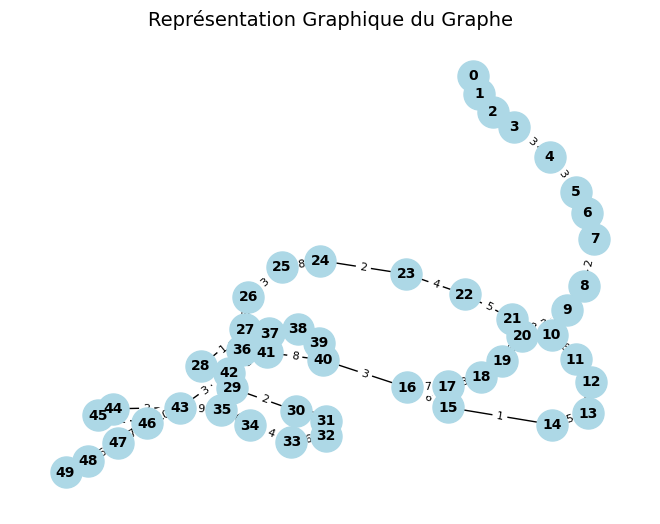

In [33]:
graph4 = generate_and_display_graph(50, 55, (1, 10), is_connected=True)


Matrice d'adjacence:
╒════╤══════╤══════╤══════╤══════╤══════╤══════╤══════╤══════╤══════╤══════╕
│    │   S0 │   S1 │   S2 │   S3 │   S4 │   S5 │   S6 │   S7 │   S8 │   S9 │
╞════╪══════╪══════╪══════╪══════╪══════╪══════╪══════╪══════╪══════╪══════╡
│  0 │    0 │    7 │    2 │   10 │    6 │    1 │    1 │    3 │    7 │   10 │
├────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┤
│  1 │    7 │    0 │    1 │    7 │    5 │    4 │    6 │    7 │   10 │    5 │
├────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┤
│  2 │    2 │    1 │    0 │    9 │    8 │    5 │    7 │    2 │   10 │    5 │
├────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┤
│  3 │   10 │    7 │    9 │    0 │    5 │    1 │    9 │    9 │    1 │    8 │
├────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┤
│  4 │    6 │    5 │    8 │    5 │    0 │    3 │   10 │    2 │    1 │    1 │
├────┼──────┼──────┼──────┼──────┼──────┼──────┼──────

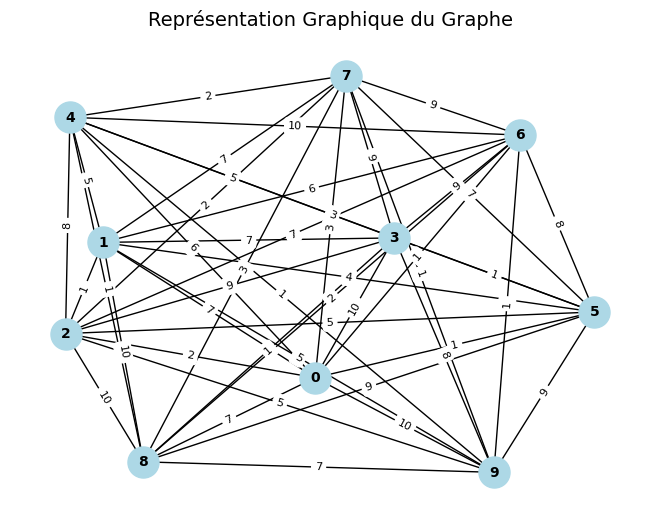

In [34]:
n_complete = 10
max_edges = (n_complete * (n_complete + 1)) // 2  # Formule du nombre d’arêtes max dans un graphe complet

graph5 = generate_and_display_graph(n_complete, max_edges, (1, 10), is_connected=True)


#### Etape 2: Calcule de distance à l'aide des deux version de l'algorithme

In [35]:
dijkstra_optimized(graph4, 4)

{0: 27,
 1: 21,
 2: 13,
 3: 3,
 4: 0,
 5: 3,
 6: 12,
 7: 18,
 8: 20,
 9: 28,
 10: 32,
 11: 40,
 12: 48,
 13: 51,
 14: 56,
 15: 57,
 16: 61,
 17: 54,
 18: 46,
 19: 37,
 20: 31,
 21: 37,
 22: 42,
 23: 46,
 24: 48,
 25: 56,
 26: 59,
 27: 64,
 28: 65,
 29: 69,
 30: 71,
 31: 79,
 32: 89,
 33: 95,
 34: 99,
 35: 92,
 36: 93,
 37: 90,
 38: 80,
 39: 73,
 40: 64,
 41: 72,
 42: 80,
 43: 83,
 44: 85,
 45: 94,
 46: 93,
 47: 100,
 48: 105,
 49: 111}

In [36]:
dijkstra_naive(graph4, 4)

{0: 27,
 1: 21,
 2: 13,
 3: 3,
 4: 0,
 5: 3,
 6: 12,
 7: 18,
 8: 20,
 9: 28,
 10: 32,
 11: 40,
 12: 48,
 13: 51,
 14: 56,
 15: 57,
 16: 61,
 17: 54,
 18: 46,
 19: 37,
 20: 31,
 21: 37,
 22: 42,
 23: 46,
 24: 48,
 25: 56,
 26: 59,
 27: 64,
 28: 65,
 29: 69,
 30: 71,
 31: 79,
 32: 89,
 33: 95,
 34: 99,
 35: 92,
 36: 93,
 37: 90,
 38: 80,
 39: 73,
 40: 64,
 41: 72,
 42: 80,
 43: 83,
 44: 85,
 45: 94,
 46: 93,
 47: 100,
 48: 105,
 49: 111}

In [37]:
dijkstra_optimized(graph5, 4)

{0: 3, 1: 5, 2: 4, 3: 2, 4: 0, 5: 3, 6: 2, 7: 2, 8: 1, 9: 1}

In [38]:
dijkstra_naive(graph5, 4)

{0: 3, 1: 5, 2: 4, 3: 2, 4: 0, 5: 3, 6: 2, 7: 2, 8: 1, 9: 1}

#### Etape 3: Comparaison entre les Deux Versions

In [39]:
compare_algorithms(graph4, 4,dijkstra_naive, dijkstra_optimized)


🔹 **Comparaison des Algorithmes de Dijkstra**
🔵 Dijkstra Naïf : 0.000361 secondes
🟢 Dijkstra Optimisé (Tas) : 0.000089 secondes
✅ L'algorithme optimisé est plus rapide.


(0.0003608000697568059, 8.939998224377632e-05)

In [40]:
compare_algorithms(graph5, 4,dijkstra_naive, dijkstra_optimized)


🔹 **Comparaison des Algorithmes de Dijkstra**
🔵 Dijkstra Naïf : 0.000096 secondes
🟢 Dijkstra Optimisé (Tas) : 0.000057 secondes
✅ L'algorithme optimisé est plus rapide.


(9.590003173798323e-05, 5.6699966080486774e-05)

#### **Version naïve** :
- Cette version repose sur **une recherche linéaire** pour **identifier le sommet avec la plus petite distance**, une opération qui **doit être répétée** pour chaque sommet.
- Dans un graphe avec un **grand nombre de sommets (V)**, cette étape devient **très coûteuse**, car elle entraîne une **complexité** :

  \[
  O(V^2)
  \]

- Si le **graphe est dense** (avec beaucoup d’arêtes), **les mises à jour des voisins** ajoutent encore à la **charge computationnelle**.
- **Limite :**  
  - Bien qu’efficace pour **des graphes de petite taille**, cette version **n’est pas adaptée** aux **grands graphes**, car elle **ne peut pas évoluer efficacement** avec l’augmentation de **V ou E**.

#### **Version optimisée** :
- Dans cette version, l’utilisation d’un **tas min** (ou **d’une file de priorité**) pour gérer les sommets prioritaires rend **le processus de sélection du sommet minimal beaucoup plus rapide** :

  \[
  O(\log V) \text{ au lieu de } O(V)
  \]

- Cela permet de **réduire considérablement le temps d’exécution global**, avec une **complexité totale** :

  \[
  O((V + E) \log V)
  \]

- Cette approche est **particulièrement adaptée aux grands graphes**, car elle traite **efficacement** à la fois **les nombreux sommets** et **les nombreuses arêtes**.
- **Avantage :**  
  - Cette version est **capable de gérer l’échelle des graphes réels**, qui comportent souvent **des millions de nœuds et d’arêtes**.

---

#### Conclusion pour les Grands Graphes

Pour **des graphes de grande taille**, la **version optimisée** est **non seulement plus rapide**, mais **également plus adaptée aux contraintes** liées à l’échelle.  

- La **réduction significative des opérations coûteuses** (grâce au **tas min**) permet à cette version de **maintenir des performances acceptables**, même lorsque **V et E augmentent considérablement**.
- Cela en fait **la solution privilégiée** pour ce type de scénario

## 8.Comparaison des performances des deux versions 

La méthode 'compare_algorithms_with_density' vise à comparer les performances des deux versions de l'algorithme de Dijkstra (naïf et optimisé avec tas) en fonction de plusieurs paramètres : l’ordre des graphes (nombre de sommets), leur densité (rapport entre le nombre d’arêtes et le nombre maximal possible), et la répétition des tests pour garantir des mesures robustes. En générant plusieurs graphes aléatoires pour chaque combinaison de paramètres, cette méthode calcule le temps moyen d’exécution des deux algorithmes et génère des graphiques alignés horizontalement. Ces graphiques permettent de visualiser les variations des temps d’exécution en fonction de la densité et de l’ordre des graphes, facilitant ainsi une analyse comparative exhaustive. L’objectif est d’illustrer comment les deux versions se comportent dans différents contextes, de graphes peu denses à très denses, et de tirer des conclusions sur leur efficacité respective.

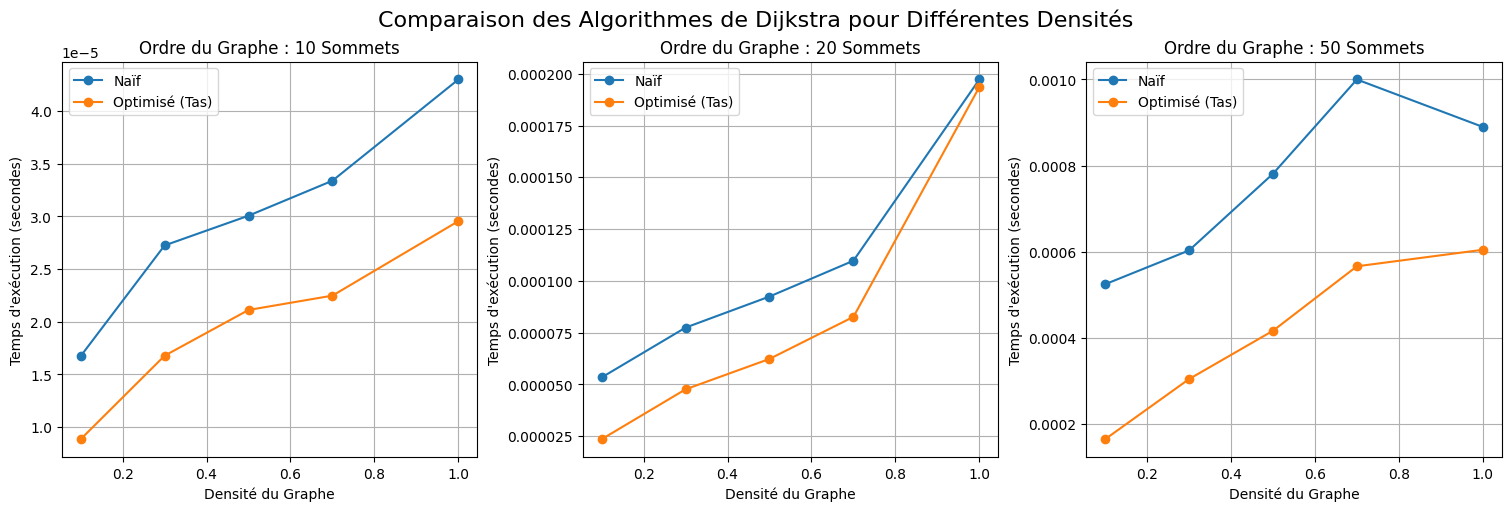

In [41]:
results = compare_algorithms_with_density(
    dijkstra_naive=dijkstra_naive,
    dijkstra_optimized=dijkstra_optimized,
    orders=[10, 20, 50],  # Graphes avec 10, 20 et 50 sommets
    densities=[0.1, 0.3, 0.5, 0.7, 1.0],  # Densités de 10% à 100%
    repetitions=5  # Répéter chaque test 5 fois
)

### Analyse des diagrammes:
Cas des petits graphes (10 sommets) :

Le temps d’exécution des deux versions augmente avec la densité.
L'algorithme optimisé est significativement plus rapide, même pour des graphes très denses (densité 1.0).
Le comportement quadratique du naïf est visible : son temps d'exécution augmente plus rapidement que celui de l'optimisé.

Cas des graphes moyens (20 sommets) :

La tendance est similaire à celle des graphes à 10 sommets.
L'écart de performance entre les deux algorithmes devient encore plus marqué à mesure que la densité augmente.
L'optimisé reste largement supérieur en termes de temps d'exécution, démontrant sa meilleure gestion des structures denses.

Cas des grands graphes (50 sommets) :

La différence de performance est encore plus prononcée.
L'algorithme naïf montre des signes évidents de limitations dues à sa complexité quadratique (O(V^2)), tandis que l’optimisé maintient une progression plus contrôlée grâce à sa complexité O((V + E) log V).
Pour des densités élevées, l’optimisé reste performant, tandis que le naïf devient lent et peu viable pour les grandes tailles.

Conclusion Comparative:

Algorithme naïf : Convient uniquement pour des graphes de petite taille et de faible densité. Son utilisation devient inefficace lorsque le nombre de sommets ou la densité augmente, en raison de sa complexité quadratique.

Algorithme optimisé : Sa complexité basée sur les tas le rend adapté à des graphes plus grands et plus denses. Il est systématiquement plus rapide dans tous les scénarios, ce qui le rend plus robuste et scalable.

## 9.Conclusion du projet

Ce projet a permis d'explorer en profondeur les performances de deux versions de l'algorithme de Dijkstra : l'implémentation naïve et la version optimisée utilisant une structure de tas. À travers une série de tests systématiques, nous avons analysé les performances des deux algorithmes en fonction de plusieurs paramètres, notamment l’ordre des graphes, leur densité, et des scénarios représentatifs allant de graphes peu connectés à des graphes denses.

Les résultats obtenus mettent en évidence des différences marquées entre les deux versions. L’algorithme naïf, bien qu’intuitif et simple à implémenter, montre rapidement ses limites en termes de scalabilité dès que la taille ou la densité des graphes augmente. En revanche, l'algorithme optimisé, grâce à sa complexité basée sur les tas, s'adapte beaucoup mieux à des graphes plus grands et plus complexes. Ces conclusions sont soutenues par des visualisations claires, qui illustrent comment l’optimisation structurelle améliore significativement les performances.

En outre, le projet a mis en œuvre une approche méthodique pour tester ces algorithmes sur des graphes aléatoires générés dynamiquement, garantissant ainsi une robustesse dans les résultats. La flexibilité du système a également permis de comparer les algorithmes dans des conditions variées, tout en produisant des visualisations exploitables pour appuyer l'analyse.

En résumé, ce projet illustre non seulement l’importance des structures de données et des optimisations algorithmiques, mais aussi la nécessité de choisir la bonne solution en fonction des contraintes spécifiques du problème. Il fournit une base solide pour des applications futures dans des domaines tels que la gestion des réseaux, la planification et l’analyse de données à grande échelle. 